In [1]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

## 1. Retrieve the files with path images

In [2]:

metadata_dir = '/export/usuarios_ml4ds/danibacaicoa/ForwardBackard_losses_old/Datasets/raw_datasets/Clothing1M/'
clean_label_kv_path = os.path.join(metadata_dir, 'clean_label_kv.txt')
noisy_label_kv_path = os.path.join(metadata_dir, 'noisy_label_kv.txt')
clean_train_key_list_path = os.path.join(metadata_dir, 'clean_train_key_list.txt')
noisy_train_key_list_path = os.path.join(metadata_dir, 'noisy_train_key_list.txt')
clean_val_key_list_path = os.path.join(metadata_dir, 'clean_val_key_list.txt')
clean_test_key_list_path = os.path.join(metadata_dir, 'clean_test_key_list.txt')
category_names_eng_path = os.path.join(metadata_dir, 'category_names_eng.txt')

# Check if files exist (optional but recommended)
required_files = [
    clean_label_kv_path, noisy_label_kv_path,
    clean_train_key_list_path, noisy_train_key_list_path,
    clean_val_key_list_path, clean_test_key_list_path,
    category_names_eng_path
]
missing_files = [f for f in required_files if not os.path.exists(f)]
if missing_files:
    print(f"Warning: The following required text files were not found:")
    for f in missing_files:
        print(f"- {f}")
    print("Please ensure these files are in the correct directory or update the paths.")
else:
    print("All required text files found.")


All required text files found.


## 2. 

In [4]:
def load_labels(filepath):
    """Loads image path -> label mapping from a file."""
    labels = {}
    try:
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 2:
                    # Use os.path.normpath to handle potential path separator issues
                    image_path = os.path.normpath(parts[0])
                    labels[image_path] = int(parts[1])
                else:
                    # Don't print warning for every line in potentially large files
                    # Consider logging or printing only once if issues are detected later
                    pass # print(f"Warning: Skipping malformed line in {filepath}: {line.strip()}")
    except FileNotFoundError:
        print(f"Error: Label file not found at {filepath}")
        return None
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None
    if not labels:
        print(f"Warning: No labels loaded from {filepath}. File might be empty or paths incorrect.")
    return labels

def load_key_list(filepath):
    """Loads a list of image paths from a file."""
    keys = []
    try:
        with open(filepath, 'r') as f:
            for line in f:
                 # Use os.path.normpath to handle potential path separator issues
                image_path = os.path.normpath(line.strip())
                if image_path: # Ensure line is not empty
                   keys.append(image_path)
    except FileNotFoundError:
        print(f"Error: Key list file not found at {filepath}")
        return None
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None
    if not keys:
         print(f"Warning: No keys loaded from {filepath}. File might be empty or paths incorrect.")
    return keys


In [5]:
# Load category names
category_names = None
try:
    if os.path.exists(category_names_eng_path):
        with open(category_names_eng_path, 'r') as f:
            category_names = [line.strip() for line in f if line.strip()]
        if category_names:
             print(f"Loaded {len(category_names)} category names.")
        else:
             print(f"Warning: Category names file {category_names_eng_path} is empty.")
             category_names = None
    else:
        print(f"Warning: Category names file not found at {category_names_eng_path}")

except Exception as e:
    print(f"Warning: Error reading {category_names_eng_path}: {e}")
    category_names = None

print(category_names)


Loaded 14 category names.
['T-Shirt', 'Shirt', 'Knitwear', 'Chiffon', 'Sweater', 'Hoodie', 'Windbreaker', 'Jacket', 'Downcoat', 'Suit', 'Shawl', 'Dress', 'Vest', 'Underwear']


In [6]:
class Clothing1MDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        """
        Args:
            root_dir (string): Directory with all the images (should contain 'images' folder).
            split (string): One of 'train', 'val', 'test'.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.split = split
        self.samples = [] # List of tuples: (image_path_relative, label, noisy_flag)

        print(f"Initializing Clothing1M dataset for split: {split}")

        # --- Load label dictionaries ---
        print("Loading label files...")
        clean_labels = load_labels(clean_label_kv_path)
        noisy_labels = load_labels(noisy_label_kv_path)
        print(f"Loaded {len(clean_labels)} clean labels and {len(noisy_labels)} noisy labels.")
        print("Checking label files...")
        print(f"Clean labels: {clean_labels}")
        print(f"Noisy labels: {noisy_labels}")
        
        # Check if label files are empty
        # Check if labels were loaded successfully
        if clean_labels is None or noisy_labels is None:
             raise RuntimeError("Failed to load label files. Cannot proceed. Check paths and file integrity.")
        print(f"Loaded {len(clean_labels)} clean labels and {len(noisy_labels)} noisy labels.")

        # --- Load the appropriate key lists based on the split ---
        print("Loading key list files...")
        if split == 'train':
            clean_keys = load_key_list(clean_train_key_list_path)
            noisy_keys = load_key_list(noisy_train_key_list_path)
            if clean_keys is None or noisy_keys is None:
                raise RuntimeError("Failed to load training key lists. Check paths and file integrity.")

            print(f"Found {len(clean_keys)} clean train keys and {len(noisy_keys)} noisy train keys.")

            # Add clean training samples
            missing_clean_labels_count = 0
            for key in clean_keys:
                if key in clean_labels:
                    self.samples.append((key, clean_labels[key], 0)) # 0 for clean
                else:
                     missing_clean_labels_count += 1
            if missing_clean_labels_count > 0:
                 print(f"Warning: {missing_clean_labels_count} clean train keys were not found in clean_label_kv.txt")

            # Add noisy training samples
            missing_noisy_labels_count = 0
            noisy_in_clean_found_count = 0
            for key in noisy_keys:
                if key in noisy_labels:
                    self.samples.append((key, noisy_labels[key], 1)) # 1 for noisy
                else:
                    # Fallback: check if it's accidentally in clean labels
                    if key in clean_labels:
                         noisy_in_clean_found_count += 1
                         self.samples.append((key, clean_labels[key], 0)) # Treat as clean if found in clean dict
                    else:
                         missing_noisy_labels_count += 1
            if noisy_in_clean_found_count > 0:
                 print(f"Warning: {noisy_in_clean_found_count} noisy train keys were found in clean_label_kv.txt instead of noisy_label_kv.txt. Labeling them as clean (noisy_flag=0).")
            if missing_noisy_labels_count > 0:
                 print(f"Warning: {missing_noisy_labels_count} noisy train keys were not found in noisy_label_kv.txt or clean_label_kv.txt")

        elif split == 'val':
            val_keys = load_key_list(clean_val_key_list_path)
            if val_keys is None:
                 raise RuntimeError("Failed to load validation key list. Check path and file integrity.")
            print(f"Found {len(val_keys)} validation keys.")
            # Validation set uses clean labels
            missing_val_labels_count = 0
            for key in val_keys:
                if key in clean_labels:
                    self.samples.append((key, clean_labels[key], 0)) # Val is clean
                else:
                    missing_val_labels_count += 1
            if missing_val_labels_count > 0:
                print(f"Warning: {missing_val_labels_count} validation keys were not found in clean_label_kv.txt")

        elif split == 'test':
            test_keys = load_key_list(clean_test_key_list_path)
            if test_keys is None:
                 raise RuntimeError("Failed to load test key list. Check path and file integrity.")
            print(f"Found {len(test_keys)} test keys.")

            # Test set uses clean labels
            missing_test_labels_count = 0
            for key in test_keys:
                if key in clean_labels:
                    self.samples.append((key, clean_labels[key], 0)) # Test is clean
                else:
                    missing_test_labels_count += 1
            if missing_test_labels_count > 0:
                print(f"Warning: {missing_test_labels_count} test keys were not found in clean_label_kv.txt")

        else:
            raise ValueError(f"Invalid split name: {split}. Choose 'train', 'val', or 'test'.")

        print(f"-> Total samples loaded for split '{split}': {len(self.samples)}")
        if len(self.samples) == 0:
             print(f"\nCRITICAL WARNING: No samples were loaded for split '{split}'.\n"
                   f"Check that the paths to the key list files ({split}_key_list.txt) and label files (clean_label_kv.txt, noisy_label_kv.txt) are correct relative to your notebook's location.\n"
                   f"Also ensure the files are not empty and have the expected format (e.g., 'images/X/Y/Z.jpg label').")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        relative_img_path, label, noisy_flag = self.samples[idx]
        # Construct full path using os.path.join for cross-platform compatibility
        img_full_path = os.path.join(self.root_dir, relative_img_path)

        try:
            # Load image
            image = Image.open(img_full_path).convert('RGB')
        except FileNotFoundError:
            # This can happen if the dataset is incomplete or paths are wrong
            # print(f"Error: Image file not found at {img_full_path}. Returning dummy data.")
            # Return dummy data or raise an error, depending on desired behavior
            image = Image.new('RGB', (224, 224), color = 'red') # Example dummy image
            label = -1 # Indicate error
            noisy_flag = -1 # Indicate error
            # Alternatively: raise FileNotFoundError(f"Image not found: {img_full_path}")
        except Exception as e:
            # Catch other PIL errors (e.g., truncated image)
            # print(f"Error loading image {img_full_path}: {e}. Returning dummy data.")
            image = Image.new('RGB', (224, 224), color = 'blue') # Different dummy color for different errors
            label = -1
            noisy_flag = -1

        # Apply transformations
        if self.transform:
            # Add a try-except block here if transforms might fail
            try:
                image = self.transform(image)
            except Exception as e:
                print(f"Error applying transform to image {img_full_path}: {e}. Returning dummy tensor.")
                image = torch.zeros((3, 224, 224), dtype=torch.float32) # Dummy tensor
                label = -1
                noisy_flag = -1

        return image, label, noisy_flag


In [7]:
# Define transforms (adjust as needed for your model)
img_size = 224
# For training: include resizing, augmentation (like horizontal flip), tensor conversion, normalization
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    # Add other augmentations like RandomCrop, ColorJitter if needed
    # transforms.RandomCrop(img_size, padding=4), # Example
    # transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1), # Example
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet stats commonly used
])

# For validation/testing: include resizing, tensor conversion, normalization (no augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transforms defined.")


Transforms defined.


In [8]:
clothing1m_root = '/export/usuarios_ml4ds/danibacaicoa/ForwardBackard_losses_old/Datasets/raw_datasets/Clothing1M/' 
#clothing1m_root = './clothing1m' # <-- CHANGE THIS TO YOUR ACTUAL PATH

# --- Directory Check ---
root_ok = False
print(f"Checking dataset root directory: {clothing1m_root}")
if not os.path.isdir(clothing1m_root):
     print(f"Error: Root directory '{clothing1m_root}' not found or is not a directory.")
     print("Please ensure the path is correct and points to the folder *containing* the 'images' directory.")
else:
    images_dir = os.path.join(clothing1m_root, 'images/')
    print(f"Checking for 'images' sub-directory: {images_dir}")
    if not os.path.isdir(images_dir):
         print(f"Error: Expected 'images' sub-directory not found inside '{clothing1m_root}'.")
         print("Please ensure the 'images' folder exists directly within the specified root directory.")
    else:
        print(f"Dataset root directory check passed: '{clothing1m_root}' contains 'images' folder.")
        root_ok = True

if not root_ok:
     print("\n!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
     print("!!! Cannot proceed without a valid dataset root directory path. !!!")
     print("!!! Please correct the 'clothing1m_root' variable and rerun.    !!!")
     print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")


Checking dataset root directory: /export/usuarios_ml4ds/danibacaicoa/ForwardBackard_losses_old/Datasets/raw_datasets/Clothing1M/
Checking for 'images' sub-directory: /export/usuarios_ml4ds/danibacaicoa/ForwardBackard_losses_old/Datasets/raw_datasets/Clothing1M/images/
Dataset root directory check passed: '/export/usuarios_ml4ds/danibacaicoa/ForwardBackard_losses_old/Datasets/raw_datasets/Clothing1M/' contains 'images' folder.



--- Creating Train Dataset ---
Initializing Clothing1M dataset for split: train
Loading label files...
Loaded 72409 clean labels and 1037497 noisy labels.
Checking label files...
Clean labels: {'images/7/88/339645240,2782721788.jpg': 9, 'images/3/32/3772565911,269049332.jpg': 4, 'images/5/05/3839087683,82531505.jpg': 8, 'images/7/80/4164884897,484083780.jpg': 9,60,3784724194.jpg': 8, 'images/5/57/2274572036,1278080557.jpg': 0, 'images/3/32/312642155,2062883332.jpg': 13, 'images/3/46/1052102659,3455190346.jpg': 8, 'images/7/76/437085079,1751782776.jpg': 11}
Loaded 72409 clean labels and 1037497 noisy labels.
Loading key list files...
Found 10526 test keys.
-> Total samples loaded for split 'test': 10526

--- Creating DataLoaders ---
Train DataLoader created with batch size 64, 16368 batches.
Validation DataLoader created with batch size 128, 112 batches.
Test DataLoader created with batch size 128, 83 batches.

--- Inspecting Training Batch ---
Successfully fetched one batch.
Images sh

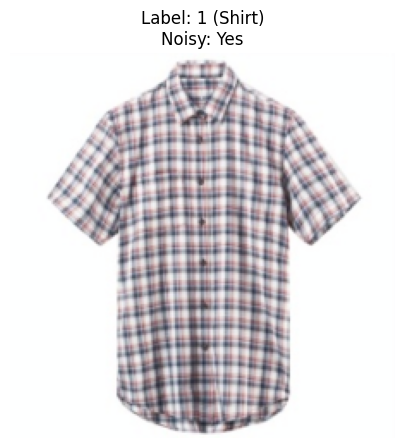

In [9]:
train_dataset = None
val_dataset = None
test_dataset = None
train_loader = None
val_loader = None
test_loader = None

# Proceed only if the root directory check passed
if root_ok:
    try:
        # Create datasets
        print("\n--- Creating Train Dataset ---")
        # Pass the already defined transform
        train_dataset = Clothing1MDataset(root_dir=clothing1m_root, split='train', transform=train_transform)

        print("\n--- Creating Validation Dataset ---")
        val_dataset = Clothing1MDataset(root_dir=clothing1m_root, split='val', transform=val_test_transform)

        print("\n--- Creating Test Dataset ---")
        test_dataset = Clothing1MDataset(root_dir=clothing1m_root, split='test', transform=val_test_transform)

        # Create dataloaders
        batch_size = 64 # Adjust as needed based on GPU memory and model size
        num_workers = 2   # Adjust based on your system's cores (start with 0 or 2); set to 0 if you encounter multiprocessing issues

        print("\n--- Creating DataLoaders ---")
        if train_dataset and len(train_dataset) > 0:
             # Consider using persistent_workers=True if num_workers > 0 for efficiency in PyTorch 1.7+
             # Set prefetch_factor=2 if using num_workers > 0
             train_loader = DataLoader(
                 train_dataset,
                 batch_size=batch_size,
                 shuffle=True,
                 num_workers=num_workers,
                 pin_memory=True, # Helps speed up CPU-to-GPU transfer if using GPU
                 # persistent_workers=True if num_workers > 0 else False, # Uncomment if needed
                 # prefetch_factor=2 if num_workers > 0 else None # Uncomment if needed
                 drop_last=True # Often useful for training stability
             )
             print(f"Train DataLoader created with batch size {batch_size}, {len(train_loader)} batches.")
        else:
             print("Skipping Train DataLoader creation as dataset is empty or failed to initialize.")

        if val_dataset and len(val_dataset) > 0:
             val_loader = DataLoader(
                 val_dataset,
                 batch_size=batch_size * 2, # Often possible to use larger batch for validation
                 shuffle=False,
                 num_workers=num_workers,
                 pin_memory=True
                 # persistent_workers=True if num_workers > 0 else False,
                 # prefetch_factor=2 if num_workers > 0 else None
             )
             print(f"Validation DataLoader created with batch size {batch_size * 2}, {len(val_loader)} batches.")
        else:
             print("Skipping Validation DataLoader creation as dataset is empty or failed to initialize.")

        if test_dataset and len(test_dataset) > 0:
             test_loader = DataLoader(
                 test_dataset,
                 batch_size=batch_size * 2,
                 shuffle=False,
                 num_workers=num_workers,
                 pin_memory=True
                 # persistent_workers=True if num_workers > 0 else False,
                 # prefetch_factor=2 if num_workers > 0 else None
             )
             print(f"Test DataLoader created with batch size {batch_size * 2}, {len(test_loader)} batches.")
        else:
             print("Skipping Test DataLoader creation as dataset is empty or failed to initialize.")

    except (RuntimeError, ValueError, FileNotFoundError) as e:
        print(f"\nAn error occurred during dataset/dataloader creation: {e}")
        print("Please double-check file paths, file contents, and the dataset root directory.")
    except Exception as e: # Catch any other unexpected errors
        import traceback
        print(f"\nAn unexpected error occurred: {e}")
        print(traceback.format_exc())
else:
    print("\nSkipping Dataset and DataLoader creation due to issues with the root directory path.")



# Example: Get one batch from the train loader if it was created
if train_loader is not None:
    print("\n--- Inspecting Training Batch ---")
    try:
        # Create an iterator and get the first batch
        data_iter = iter(train_loader)
        images, labels, noisy_flags = next(data_iter) # This fetches one batch

        print("Successfully fetched one batch.")
        print("Images shape:", images.shape)      # Example: [batch_size, 3, 224, 224]
        print("Labels shape:", labels.shape)        # Example: [batch_size]
        print("Noisy flags shape:", noisy_flags.shape) # Example: [batch_size]

        # --- Inspect the first item in the batch ---
        print("\nExample data from the first item in the batch:")
        first_label = labels[0].item()
        first_noisy_flag = noisy_flags[0].item()
        print("Label:", first_label)
        print("Is Noisy:", "Yes" if first_noisy_flag == 1 else "No (Clean)")

        # Print category name if available and label is valid
        if category_names:
            if 0 <= first_label < len(category_names):
                 print("Category Name:", category_names[first_label])
            elif first_label == -1:
                 print("Category Name: Invalid label due to loading error (-1)")
            else:
                 print(f"Category Name: Invalid label index ({first_label}) for category names list (len={len(category_names)})")
        else:
            print("Category names not loaded.")

        # --- Display the first image in the batch ---
        print("\nDisplaying first image (denormalized):")
        first_image = images[0] # Get the first image tensor from the batch
        # Convert CHW tensor to HWC numpy array for display
        img_display = first_image.permute(1, 2, 0).cpu().numpy()

        # Denormalize the image (reverse the normalization applied by transforms)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1) # Clip values to [0, 1] range

        plt.figure(figsize=(5,5))
        plt.imshow(img_display)
        title = f'Label: {first_label}'
        if category_names and 0 <= first_label < len(category_names):
            title += f' ({category_names[first_label]})'
        title += f'\nNoisy: {"Yes" if first_noisy_flag == 1 else "No"}'
        plt.title(title)
        plt.axis('off') # Hide axes
        plt.show()

    except StopIteration:
        print("Could not fetch a batch. The train loader appears to be empty or exhausted.")
    except Exception as e:
        print(f"An error occurred while fetching or inspecting the batch: {e}")
        import traceback
        print(traceback.format_exc())
else:
    print("\nTrain loader is not available (was not created successfully or root path was invalid). Cannot inspect batch.")


Determined number of classes: 14

Estimating Transition Matrix directly from label files...
Loading clean labels from file...
Loading noisy labels from file...
Found 72409 clean label entries and 1037497 noisy label entries.
Found 37497 images present in both clean and noisy label sets.

Raw Count Matrix (Rows=Clean, Cols=Noisy):
[[1798   84  199   64   42  166    1   78    3    7    1  195   39  127]
 [ 231 2205   32  130    4    8   11   88    7   38    1  138   11    8]
 [ 188   31  607   10  379   33   10    7    1    5   23   96   25   14]
 [ 601  823   62 1820    5   11    6    9    0    4    1  518   90    1]
 [ 296   13 1280    9  230   54    6    3    0    2    4   89   26   42]
 [  75   29  108    5   18 1980   96  488   30   28    2   14   28   31]
 [   3   23   27    0    2   34 1232  180  445  103   11   83    6    5]
 [   6   99    0    0    0   36  303  586   47    3    1   44   13    0]
 [  13   28    6    2    1   52  560  410 1667   11   16   13  344   16]
 [  16   24

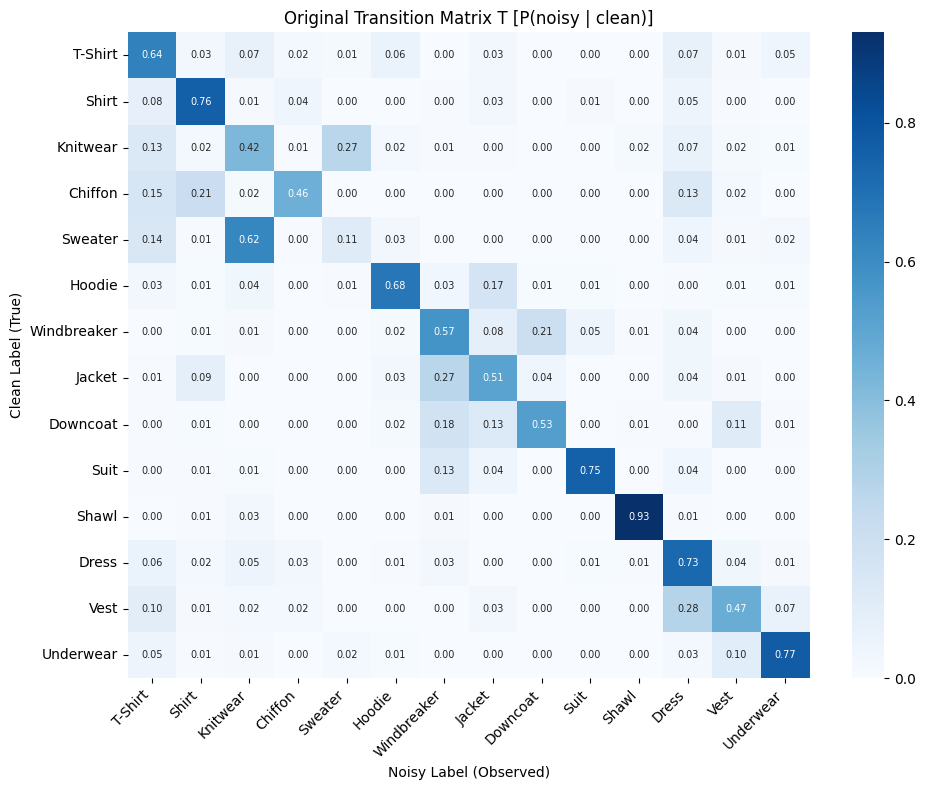

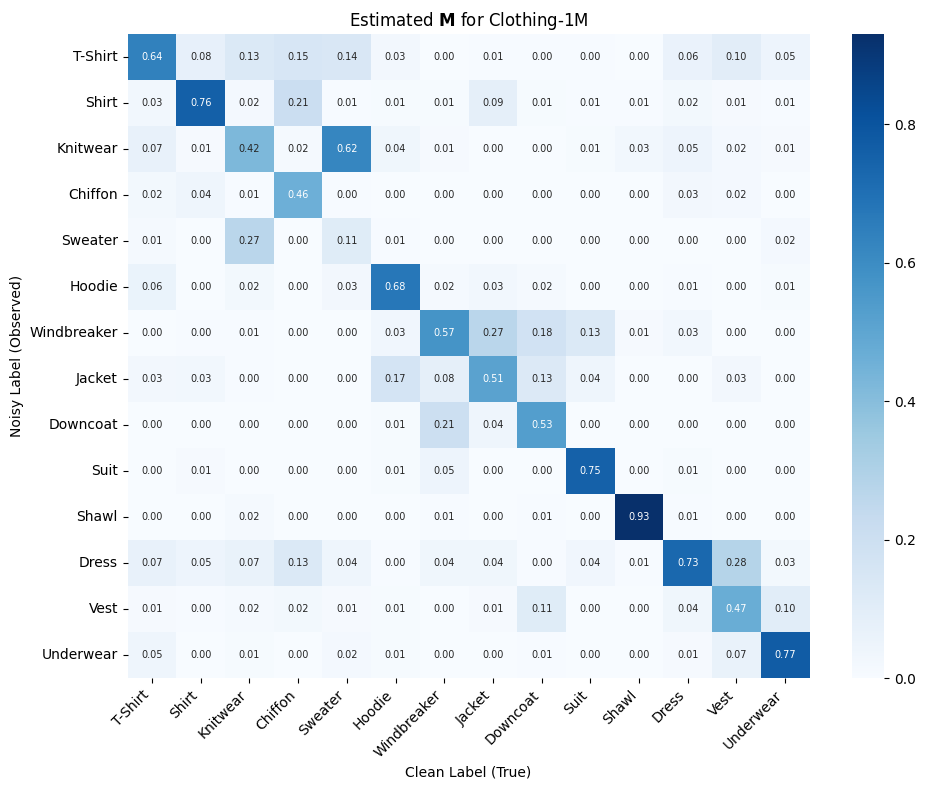

In [9]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- Re-use necessary helper functions and variables ---

# Function from previous cell (ensure it's defined)
def load_labels(filepath):
    """Loads image path -> label mapping from a file."""
    labels = {}
    try:
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 2:
                    image_path = os.path.normpath(parts[0])
                    labels[image_path] = int(parts[1])
    except FileNotFoundError:
        print(f"Error: Label file not found at {filepath}")
        return None
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None
    if not labels:
        print(f"Warning: No labels loaded from {filepath}. File might be empty or paths incorrect.")
    return labels

# Define file paths (ensure metadata_dir is set correctly)
# !! Use the path provided by the user !!
metadata_dir = '/export/usuarios_ml4ds/danibacaicoa/ForwardBackard_losses_old/Datasets/raw_datasets/Clothing1M/' # <-- User provided path

clean_label_kv_path = os.path.join(metadata_dir, 'clean_label_kv.txt')
noisy_label_kv_path = os.path.join(metadata_dir, 'noisy_label_kv.txt')
category_names_eng_path = os.path.join(metadata_dir, 'category_names_eng.txt')

# Determine number of classes
num_classes = 0
category_names = None # Initialize category_names
try:
    if os.path.exists(category_names_eng_path):
        with open(category_names_eng_path, 'r') as f:
            category_names = [line.strip() for line in f if line.strip()]
            num_classes = len(category_names)
        print(f"Determined number of classes: {num_classes}")
    else:
        print(f"Warning: Category names file not found at {category_names_eng_path}.")
        num_classes = 14 # Default for Clothing1M
        print(f"Assuming default num_classes for Clothing1M: {num_classes}")
except Exception as e:
    print(f"Error reading category names file: {e}")
    num_classes = 14
    print(f"Assuming default num_classes for Clothing1M: {num_classes}")

# --- Function to Estimate Transition Matrix ---

def estimate_transition_matrix(clean_labels_path, noisy_labels_path, num_classes):
    """
    Estimates the transition matrix T where T[i, j] = P(noisy=j | clean=i)
    by comparing full clean and noisy label mappings.

    Args:
        clean_labels_path (str): Path to the clean label file (e.g., clean_label_kv.txt).
        noisy_labels_path (str): Path to the noisy label file (e.g., noisy_label_kv.txt).
        num_classes (int): The total number of classes.

    Returns:
        numpy.ndarray: The estimated transition matrix (num_classes x num_classes),
                       or None if loading fails.
    """
    print("Loading clean labels from file...")
    clean_labels = load_labels(clean_labels_path)
    print("Loading noisy labels from file...")
    noisy_labels = load_labels(noisy_labels_path)

    if clean_labels is None or noisy_labels is None:
        print("Error: Failed to load one or both label files. Cannot estimate matrix.")
        return None

    if num_classes <= 0:
        print("Error: num_classes must be positive.")
        return None

    print(f"Found {len(clean_labels)} clean label entries and {len(noisy_labels)} noisy label entries.")

    common_keys = set(clean_labels.keys()) & set(noisy_labels.keys())
    print(f"Found {len(common_keys)} images present in both clean and noisy label sets.")

    if not common_keys:
        print("Error: No common images found between clean and noisy sets. Cannot estimate matrix.")
        return None

    count_matrix = np.zeros((num_classes, num_classes), dtype=float)
    invalid_labels_count = 0
    for key in common_keys:
        clean_label = clean_labels[key]
        noisy_label = noisy_labels[key]
        if 0 <= clean_label < num_classes and 0 <= noisy_label < num_classes:
            count_matrix[clean_label, noisy_label] += 1.0
        else:
            invalid_labels_count += 1
    if invalid_labels_count > 0:
         print(f"Warning: Skipped {invalid_labels_count} pairs due to invalid label indices (out of bounds).")

    print("\nRaw Count Matrix (Rows=Clean, Cols=Noisy):")
    with np.printoptions(threshold=np.inf, suppress=True):
         print(count_matrix.astype(int))

    epsilon = 1e-8
    row_sums = count_matrix.sum(axis=1, keepdims=True)
    zero_sum_rows = np.where(row_sums < epsilon)[0]
    if len(zero_sum_rows) > 0:
        print(f"\nWarning: The following clean classes had no samples in the clean/noisy intersection:")
        print(f"Indices: {zero_sum_rows}")
        if category_names: print(f"Names: {[category_names[i] for i in zero_sum_rows]}")
        print("Their rows in the transition matrix will be zero.")

    transition_matrix = count_matrix / (row_sums + epsilon)
    return transition_matrix

# --- Main Execution ---
if num_classes > 0:
    print("\nEstimating Transition Matrix directly from label files...")
    T = estimate_transition_matrix(clean_label_kv_path, noisy_label_kv_path, num_classes)

    if T is not None:
        print("\nOriginal Estimated Transition Matrix T (Rows=Clean, Cols=Noisy):")
        np.set_printoptions(precision=3, suppress=True)
        print(T)
        print(f"\nMatrix T shape: {T.shape}")

        # --- Calculate and Print Transposed Matrix ---
        T_transpose = T.T
        print("\nTransposed Transition Matrix T_transpose (Rows=Noisy, Cols=Clean):")
        print(T_transpose)
        print(f"\nMatrix T_transpose shape: {T_transpose.shape}")
        print("\nReminder: T_transpose[j, i] still represents P(noisy=j | clean=i)")

        # --- Visualize Both Matrices ---
        tick_labels = category_names if category_names and len(category_names) == num_classes else range(num_classes)
        plot_annot_kws={"size": 7} # Smaller font size for annotations

        try:
            # Visualize Original T
            plt.figure(figsize=(10, 8))
            sns.heatmap(T, annot=True, fmt=".2f", cmap="Blues",
                        xticklabels=tick_labels, yticklabels=tick_labels, annot_kws=plot_annot_kws)
            plt.xlabel("Noisy Label (Observed)")
            plt.ylabel("Clean Label (True)")
            plt.title("Original Transition Matrix T [P(noisy | clean)]")
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()

            # Visualize Transposed T
            plt.figure(figsize=(10, 8))
            # NOTE: Use T_transpose, and swap axis labels/titles
            sns.heatmap(T_transpose, annot=True, fmt=".2f", cmap="Blues",
                        xticklabels=tick_labels, yticklabels=tick_labels, annot_kws=plot_annot_kws)
            plt.xlabel("Clean Label (True)")  # <--- Swapped Label
            plt.ylabel("Noisy Label (Observed)") # <--- Swapped Label
            plt.title(r'Estimated $\mathbf{M}$ for Clothing-1M')# <--- Updated Title
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"\nCould not visualize matrices: {e}")
            print("Ensure matplotlib and seaborn are installed (`pip install matplotlib seaborn`)")

else:
    print("\nCannot estimate matrix because num_classes was not determined.")


In [11]:
M = T.T

In [12]:
M

array([[0.641, 0.079, 0.132, 0.152, 0.144, 0.026, 0.001, 0.005, 0.004,
        0.005, 0.003, 0.062, 0.1  , 0.048],
       [0.03 , 0.757, 0.022, 0.208, 0.006, 0.01 , 0.011, 0.087, 0.009,
        0.007, 0.006, 0.022, 0.014, 0.005],
       [0.071, 0.011, 0.425, 0.016, 0.623, 0.037, 0.013, 0.   , 0.002,
        0.01 , 0.03 , 0.049, 0.022, 0.012],
       [0.023, 0.045, 0.007, 0.461, 0.004, 0.002, 0.   , 0.   , 0.001,
        0.002, 0.002, 0.027, 0.019, 0.   ],
       [0.015, 0.001, 0.265, 0.001, 0.112, 0.006, 0.001, 0.   , 0.   ,
        0.001, 0.002, 0.004, 0.   , 0.019],
       [0.059, 0.003, 0.023, 0.003, 0.026, 0.675, 0.016, 0.032, 0.017,
        0.002, 0.001, 0.006, 0.001, 0.009],
       [0.   , 0.004, 0.007, 0.002, 0.003, 0.033, 0.572, 0.266, 0.178,
        0.133, 0.012, 0.032, 0.   , 0.001],
       [0.028, 0.03 , 0.005, 0.002, 0.001, 0.166, 0.084, 0.515, 0.131,
        0.044, 0.001, 0.003, 0.028, 0.001],
       [0.001, 0.002, 0.001, 0.   , 0.   , 0.01 , 0.207, 0.041, 0.531,
        0

In [ ]:
import numpy as np

# Given matrix M
'''
M = np.array([
    [0.641, 0.079, 0.132, 0.152, 0.144, 0.026, 0.001, 0.005, 0.004, 0.005, 0.003, 0.062, 0.1,   0.048],
    [0.03,  0.757, 0.022, 0.208, 0.006, 0.01,  0.011, 0.087, 0.009, 0.007, 0.006, 0.022, 0.014, 0.005],
    [0.071, 0.011, 0.425, 0.016, 0.623, 0.037, 0.013, 0.0,   0.002, 0.01,  0.03,  0.049, 0.022, 0.012],
    [0.023, 0.045, 0.007, 0.461, 0.004, 0.002, 0.0,   0.0,   0.001, 0.002, 0.002, 0.027, 0.019, 0.0],
    [0.015, 0.001, 0.265, 0.001, 0.112, 0.006, 0.001, 0.0,   0.0,   0.001, 0.002, 0.004, 0.0,   0.019],
    [0.059, 0.003, 0.023, 0.003, 0.026, 0.675, 0.016, 0.032, 0.017, 0.002, 0.001, 0.006, 0.001, 0.009],
    [0.0,   0.004, 0.007, 0.002, 0.003, 0.033, 0.572, 0.266, 0.178, 0.133, 0.012, 0.032, 0.0,   0.001],
    [0.028, 0.03,  0.005, 0.002, 0.001, 0.166, 0.084, 0.515, 0.131, 0.044, 0.001, 0.003, 0.028, 0.001],
    [0.001, 0.002, 0.001, 0.0,   0.0,   0.01,  0.207, 0.041, 0.531, 0.001, 0.0,   0.001, 0.0,   0.0],
    [0.002, 0.013, 0.003, 0.001, 0.001, 0.01,  0.048, 0.003, 0.004, 0.754, 0.003, 0.009, 0.0,   0.002],
    [0.0,   0.0,   0.016, 0.0,   0.002, 0.001, 0.005, 0.001, 0.005, 0.002, 0.93,  0.006, 0.0,   0.001],
    [0.07,  0.047, 0.067, 0.131, 0.043, 0.005, 0.039, 0.039, 0.004, 0.036, 0.006, 0.73,  0.281, 0.025],
    [0.014, 0.004, 0.017, 0.023, 0.013, 0.01,  0.003, 0.011, 0.11,  0.003, 0.004, 0.039, 0.47,  0.103],
    [0.045, 0.003, 0.01,  0.0,   0.02,  0.011, 0.002, 0.0,   0.005, 0.0,   0.001, 0.012, 0.066, 0.771]
])
'''
n = M.shape[0]
eps = 1e-2
lr = 1e-1

# Initialize A in (eps, 1-eps), B >= 0, both column-stochastic
rng = np.random.default_rng(42)
A = rng.uniform(eps, 1-eps, size=(n,n))
A /= A.sum(axis=0, keepdims=True)
B = rng.random((n,n))
B /= B.sum(axis=0, keepdims=True)

# Alternating projected gradient descent
err = 999
it = 0
while err > 1e-3:
    # gradient w.r.t. A
    gradA = (A.dot(B) - M).dot(B.T)
    A -= lr * gradA
    # project A to [eps,1-eps] and column-normalize
    A = np.clip(A, eps, 1-eps)
    A /= A.sum(axis=0, keepdims=True)

    # gradient w.r.t. B
    gradB = A.T.dot(A.dot(B) - M)
    B -= lr * gradB
    # project B to [0, inf) and column-normalize
    B = np.maximum(B, 0)
    B /= B.sum(axis=0, keepdims=True)

    err = np.linalg.norm(A.dot(B) - M, 'fro')
# Final error
error = np.linalg.norm(A.dot(B) - M, 'fro')
print(f"\nFinal Frobenius error after {it} iterations: {error:.6e}")

# A and B now satisfy:
# - A in (0,1)^{14x14}, column-stochastic
# - B >= 0, column-stochastic
# - A @ B ≈ M


KeyboardInterrupt: 

In [16]:
err

999

In [16]:
A = np.array([
       [0.641, 0.079, 0.132, 0.152, 0.144, 0.026, 0.001, 0.005, 0.004, 0.005, 0.003, 0.062, 0.1  , 0.048],
       [0.03 , 0.757, 0.022, 0.208, 0.006, 0.01 , 0.011, 0.087, 0.009, 0.007, 0.006, 0.022, 0.014, 0.005],
       [0.071, 0.011, 0.425, 0.016, 0.623, 0.037, 0.013, 0.   , 0.002, 0.01 , 0.03 , 0.049, 0.022, 0.012],
       [0.023, 0.045, 0.007, 0.461, 0.004, 0.002, 0.   , 0.   , 0.001, 0.002, 0.002, 0.027, 0.019, 0.   ],
       [0.015, 0.001, 0.265, 0.001, 0.112, 0.006, 0.001, 0.   , 0.   , 0.001, 0.002, 0.004, 0.   , 0.019],
       [0.059, 0.003, 0.023, 0.003, 0.026, 0.675, 0.016, 0.032, 0.017, 0.002, 0.001, 0.006, 0.001, 0.009],
       [0.   , 0.004, 0.007, 0.002, 0.003, 0.033, 0.572, 0.266, 0.178, 0.133, 0.012, 0.032, 0.   , 0.001],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]
       ])

I = np.array([
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [30]:
A= np.eye(14)*0.5 + np.random.rand(14, 14)*0.01
print(A)
B = A/np.sum(A, axis=0, keepdims=True)
print(B)

[[0.507 0.002 0.008 0.004 0.006 0.001 0.006 0.005 0.008 0.008 0.003 0.002
  0.    0.003]
 [0.008 0.508 0.003 0.001 0.005 0.004 0.002 0.007 0.008 0.006 0.008 0.009
  0.001 0.01 ]
 [0.006 0.    0.504 0.005 0.003 0.001 0.007 0.    0.001 0.001 0.007 0.006
  0.009 0.002]
 [0.001 0.004 0.006 0.506 0.003 0.005 0.01  0.004 0.004 0.    0.002 0.007
  0.005 0.004]
 [0.008 0.001 0.004 0.01  0.507 0.004 0.009 0.003 0.01  0.009 0.001 0.008
  0.007 0.006]
 [0.006 0.007 0.005 0.004 0.005 0.506 0.    0.008 0.001 0.003 0.003 0.009
  0.001 0.01 ]
 [0.008 0.009 0.008 0.004 0.007 0.005 0.508 0.001 0.006 0.007 0.008 0.
  0.002 0.009]
 [0.009 0.009 0.007 0.006 0.007 0.008 0.007 0.51  0.003 0.    0.006 0.009
  0.004 0.01 ]
 [0.004 0.007 0.003 0.008 0.003 0.004 0.002 0.009 0.506 0.008 0.004 0.009
  0.002 0.01 ]
 [0.001 0.004 0.008 0.004 0.002 0.009 0.008 0.007 0.003 0.508 0.001 0.002
  0.    0.   ]
 [0.006 0.003 0.005 0.005 0.    0.    0.002 0.001 0.01  0.002 0.509 0.003
  0.007 0.007]
 [0.007 0.004 0.008 0.00

In [21]:
B

array([[0.764, 0.088, 0.15 , 0.18 , 0.157, 0.033, 0.002, 0.004, 0.003,
        0.004, 0.003, 0.052, 0.087, 0.044],
       [0.036, 0.841, 0.025, 0.247, 0.007, 0.013, 0.018, 0.063, 0.007,
        0.006, 0.006, 0.018, 0.012, 0.005],
       [0.085, 0.012, 0.482, 0.019, 0.679, 0.047, 0.021, 0.   , 0.002,
        0.009, 0.028, 0.041, 0.019, 0.011],
       [0.027, 0.05 , 0.008, 0.547, 0.004, 0.003, 0.   , 0.   , 0.001,
        0.002, 0.002, 0.022, 0.016, 0.   ],
       [0.018, 0.001, 0.301, 0.001, 0.122, 0.008, 0.002, 0.   , 0.   ,
        0.001, 0.002, 0.003, 0.   , 0.017],
       [0.07 , 0.003, 0.026, 0.004, 0.028, 0.856, 0.026, 0.023, 0.014,
        0.002, 0.001, 0.005, 0.001, 0.008],
       [0.   , 0.004, 0.008, 0.002, 0.003, 0.042, 0.932, 0.191, 0.147,
        0.115, 0.011, 0.027, 0.   , 0.001],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.719, 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.826,
        0

In [26]:
np.sum(B,axis=1,keepdims=True)

array([[1.569],
       [1.302],
       [1.454],
       [0.682],
       [0.476],
       [1.067],
       [1.483],
       [0.719],
       [0.826],
       [0.862],
       [0.947],
       [0.832],
       [0.865],
       [0.914]])

In [31]:
import numpy as np

# Matrix M (first array provided in the prompt)
M = np.array([[0.641, 0.079, 0.132, 0.152, 0.144, 0.026, 0.001, 0.005, 0.004, 0.005, 0.003, 0.062, 0.1  , 0.048],
       [0.03 , 0.757, 0.022, 0.208, 0.006, 0.01 , 0.011, 0.087, 0.009, 0.007, 0.006, 0.022, 0.014, 0.005],
       [0.071, 0.011, 0.425, 0.016, 0.623, 0.037, 0.013, 0.   , 0.002, 0.01 , 0.03 , 0.049, 0.022, 0.012],
       [0.023, 0.045, 0.007, 0.461, 0.004, 0.002, 0.   , 0.   , 0.001, 0.002, 0.002, 0.027, 0.019, 0.   ],
       [0.015, 0.001, 0.265, 0.001, 0.112, 0.006, 0.001, 0.   , 0.   , 0.001, 0.002, 0.004, 0.   , 0.019],
       [0.059, 0.003, 0.023, 0.003, 0.026, 0.675, 0.016, 0.032, 0.017, 0.002, 0.001, 0.006, 0.001, 0.009],
       [0.   , 0.004, 0.007, 0.002, 0.003, 0.033, 0.572, 0.266, 0.178, 0.133, 0.012, 0.032, 0.   , 0.001],
       [0.028, 0.03 , 0.005, 0.002, 0.001, 0.166, 0.084, 0.515, 0.131, 0.044, 0.001, 0.003, 0.028, 0.001],
       [0.001, 0.002, 0.001, 0.   , 0.   , 0.01 , 0.207, 0.041, 0.531, 0.001, 0.   , 0.001, 0.   , 0.   ],
       [0.002, 0.013, 0.003, 0.001, 0.001, 0.01 , 0.048, 0.003, 0.004, 0.754, 0.003, 0.009, 0.   , 0.002],
       [0.   , 0.   , 0.016, 0.   , 0.002, 0.001, 0.005, 0.001, 0.005, 0.002, 0.93 , 0.006, 0.   , 0.001],
       [0.07 , 0.047, 0.067, 0.131, 0.043, 0.005, 0.039, 0.039, 0.004, 0.036, 0.006, 0.73 , 0.281, 0.025],
       [0.014, 0.004, 0.017, 0.023, 0.013, 0.01 , 0.003, 0.011, 0.11 , 0.003, 0.004, 0.039, 0.47 , 0.103],
       [0.045, 0.003, 0.01 , 0.   , 0.02 , 0.011, 0.002, 0.   , 0.005, 0.   , 0.001, 0.012, 0.066, 0.771]])

'''
A = np.array([[0.764, 0.088, 0.15 , 0.18 , 0.157, 0.033, 0.002, 0.004, 0.003, 0.004, 0.003, 0.052, 0.087, 0.044],
       [0.036, 0.841, 0.025, 0.247, 0.007, 0.013, 0.018, 0.063, 0.007, 0.006, 0.006, 0.018, 0.012, 0.005],
       [0.085, 0.012, 0.482, 0.019, 0.679, 0.047, 0.021, 0.   , 0.002, 0.009, 0.028, 0.041, 0.019, 0.011],
       [0.027, 0.05 , 0.008, 0.547, 0.004, 0.003, 0.   , 0.   , 0.001, 0.002, 0.002, 0.022, 0.016, 0.   ],
       [0.018, 0.001, 0.301, 0.001, 0.122, 0.008, 0.002, 0.   , 0.   , 0.001, 0.002, 0.003, 0.   , 0.017],
       [0.07 , 0.003, 0.026, 0.004, 0.028, 0.856, 0.026, 0.023, 0.014, 0.002, 0.001, 0.005, 0.001, 0.008],
       [0.   , 0.004, 0.008, 0.002, 0.003, 0.042, 0.932, 0.191, 0.147, 0.115, 0.011, 0.027, 0.   , 0.001],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.719, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.826, 0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.862, 0.   , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.947, 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.832, 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.865, 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.914]])
'''
# Step 1: Check if A is invertible
det_A = np.linalg.det(A)

if np.isclose(det_A, 0):
    print("Matrix A is singular (or close to singular).")
    print("An exact unique solution B for A @ B = M may not exist, or there might be infinitely many.")
    # Further analysis (like rank checks or attempting pseudo-inverse/least squares)
    # would be needed, but finding a *stochastic* solution under these conditions
    # typically requires constrained optimization methods.
    B = None # Cannot easily find B
else:
    print("Matrix A is invertible.")
    # Step 2: Calculate the unique solution B using np.linalg.solve for numerical stability
    try:
        B = np.linalg.solve(A, M)
        print("Calculated the unique solution B = solve(A, M).")
        # Verify the solution
        if not np.allclose(A @ B, M):
             print("Verification failed: A @ B is not close to M. This might indicate numerical issues.")
             B = None # Treat solution as unreliable
        else:
             print("Verification successful: A @ B is close to M.")

    except np.linalg.LinAlgError:
        print("Solving A @ B = M failed, possibly due to A being ill-conditioned.")
        B = None

# Step 3: If B was found, check if it's column stochastic
if B is not None:
    print("\nChecking if B is column stochastic:")
    # Check non-negativity (allowing for small numerical errors like -1e-15)
    is_non_negative = (B >= -1e-9).all()
    # Check column sums
    column_sums = np.sum(B, axis=0)
    sums_equal_one = np.allclose(column_sums, 1)

    print(f"Is B non-negative? {is_non_negative}")
    print(f"Do columns of B sum to 1? {sums_equal_one}")
    if not is_non_negative:
        print(" -> B contains negative entries.")
    if not sums_equal_one:
        print(f" -> B column sums are: {column_sums}")

    if is_non_negative and sums_equal_one:
        print("\nConclusion: The calculated matrix B satisfies A @ B = M and is column stochastic.")
        # You can uncomment the line below to print the matrix B
        # print("Matrix B:\n", B)
    else:
        print("\nConclusion: The unique matrix B satisfying A @ B = M is NOT column stochastic.")
        print("Therefore, no matrix B exists that satisfies both conditions.")

elif B is None:
    print("\nConclusion: Could not find a matrix B satisfying A @ B = M.")

Matrix A is invertible.
Calculated the unique solution B = solve(A, M).
Verification successful: A @ B is close to M.

Checking if B is column stochastic:
Is B non-negative? False
Do columns of B sum to 1? False
 -> B contains negative entries.
 -> B column sums are: [1.716 1.762 1.734 1.738 1.711 1.771 1.731 1.75  1.764 1.745 1.765 1.71
 1.766 1.688]

Conclusion: The unique matrix B satisfying A @ B = M is NOT column stochastic.
Therefore, no matrix B exists that satisfies both conditions.


In [36]:
import numpy as np
from scipy.linalg import logm, expm

# Matrix M (original matrix)
M = np.array([[0.641, 0.079, 0.132, 0.152, 0.144, 0.026, 0.001, 0.005, 0.004, 0.005, 0.003, 0.062, 0.1  , 0.048],
       [0.03 , 0.757, 0.022, 0.208, 0.006, 0.01 , 0.011, 0.087, 0.009, 0.007, 0.006, 0.022, 0.014, 0.005],
       [0.071, 0.011, 0.425, 0.016, 0.623, 0.037, 0.013, 0.   , 0.002, 0.01 , 0.03 , 0.049, 0.022, 0.012],
       [0.023, 0.045, 0.007, 0.461, 0.004, 0.002, 0.   , 0.   , 0.001, 0.002, 0.002, 0.027, 0.019, 0.   ],
       [0.015, 0.001, 0.265, 0.001, 0.112, 0.006, 0.001, 0.   , 0.   , 0.001, 0.002, 0.004, 0.   , 0.019],
       [0.059, 0.003, 0.023, 0.003, 0.026, 0.675, 0.016, 0.032, 0.017, 0.002, 0.001, 0.006, 0.001, 0.009],
       [0.   , 0.004, 0.007, 0.002, 0.003, 0.033, 0.572, 0.266, 0.178, 0.133, 0.012, 0.032, 0.   , 0.001],
       [0.028, 0.03 , 0.005, 0.002, 0.001, 0.166, 0.084, 0.515, 0.131, 0.044, 0.001, 0.003, 0.028, 0.001],
       [0.001, 0.002, 0.001, 0.   , 0.   , 0.01 , 0.207, 0.041, 0.531, 0.001, 0.   , 0.001, 0.   , 0.   ],
       [0.002, 0.013, 0.003, 0.001, 0.001, 0.01 , 0.048, 0.003, 0.004, 0.754, 0.003, 0.009, 0.   , 0.002],
       [0.   , 0.   , 0.016, 0.   , 0.002, 0.001, 0.005, 0.001, 0.005, 0.002, 0.93 , 0.006, 0.   , 0.001],
       [0.07 , 0.047, 0.067, 0.131, 0.043, 0.005, 0.039, 0.039, 0.004, 0.036, 0.006, 0.73 , 0.281, 0.025],
       [0.014, 0.004, 0.017, 0.023, 0.013, 0.01 , 0.003, 0.011, 0.11 , 0.003, 0.004, 0.039, 0.47 , 0.103],
       [0.045, 0.003, 0.01 , 0.   , 0.02 , 0.011, 0.002, 0.   , 0.005, 0.   , 0.001, 0.012, 0.066, 0.771]])

# Choose epsilon
eps = 1e-8

# Create M_prime
print(f"Creating M_prime using eps = {eps}")
M_eps = M + eps
column_sums_eps = np.sum(M_eps, axis=0)
# Ensure no column sum is zero before division
if np.any(column_sums_eps == 0):
    print("Warning: A column sum is zero after adding epsilon.")
    # Handle error or set sums to 1
    column_sums_eps[column_sums_eps == 0] = 1
M_prime = M_eps / column_sums_eps[np.newaxis, :]

# Verify M_prime properties
print("\nVerifying M_prime properties:")
is_positive = (M_prime > 0).all()
is_stochastic = np.allclose(np.sum(M_prime, axis=0), 1)
print(f"Is M_prime positive? {is_positive}")
print(f"Is M_prime column stochastic? {is_stochastic}")

if not (is_positive and is_stochastic):
    print("M_prime did not meet requirements. Stopping.")
else:
    print("\nAttempting decomposition M_prime = P @ Q using matrix powers (a=0.3)...")
    P_final = None
    Q_final = None
    I = np.identity(M_prime.shape[0]) # Identity matrix for checks

    try:
        log_M_prime = logm(M_prime) # Matrix logarithm

        # Choose a fraction a != 0.5, e.g., a = 0.3
        a = 0.3
        P_pow = expm(a * log_M_prime) # P = M_prime^a
        Q_pow = expm((1 - a) * log_M_prime) # Q = M_prime^(1-a)

        # --- Check Results ---
        # Treat negligible imaginary parts as zero
        if not np.isreal(P_pow).all() and np.allclose(np.imag(P_pow), 0): P_pow = np.real(P_pow)
        if not np.isreal(Q_pow).all() and np.allclose(np.imag(Q_pow), 0): Q_pow = np.real(Q_pow)

        print("\nChecking candidate matrices P and Q:")
        # Check if real
        p_is_real = np.isreal(P_pow).all()
        q_is_real = np.isreal(Q_pow).all()
        print(f"Is P real? {p_is_real}")
        print(f"Is Q real? {q_is_real}")

        if p_is_real and q_is_real:
            # Check product reconstruction
            product_check = np.allclose(P_pow @ Q_pow, M_prime)
            print(f"Does P @ Q reconstruct M_prime? {product_check}")

            # Check positivity (use tolerance)
            p_is_positive = (P_pow > 1e-9).all()
            q_is_positive = (Q_pow > 1e-9).all()
            print(f"Is P positive? {p_is_positive}")
            print(f"Is Q positive? {q_is_positive}")

            # Check stochasticity (use tolerance)
            p_is_stochastic = np.allclose(np.sum(P_pow, axis=0), 1)
            q_is_stochastic = np.allclose(np.sum(Q_pow, axis=0), 1)
            print(f"Is P column stochastic? {p_is_stochastic}")
            print(f"Is Q column stochastic? {q_is_stochastic}")

            # Check constraints
            p_is_identity = np.allclose(P_pow, I)
            q_is_identity = np.allclose(Q_pow, I)
            p_equals_q = np.allclose(P_pow, Q_pow)
            print(f"Is P identity? {p_is_identity}")
            print(f"Is Q identity? {q_is_identity}")
            print(f"Is P equal to Q? {p_equals_q}")

            # Verify all conditions are met
            if (product_check and
                p_is_positive and q_is_positive and
                p_is_stochastic and q_is_stochastic and
                not p_is_identity and not q_is_identity and not p_equals_q):
                print("\nSuccess! Found decomposition P, Q satisfying all conditions.")
                P_final = P_pow
                Q_final = Q_pow
            else:
                print("\nFailed: The calculated P and Q do not meet all specified conditions.")
        else:
            print("\nFailed: P or Q resulted in complex matrices.")

    except Exception as e:
        print(f"\nError during matrix power calculation: {e}")
        print("This might happen if M_prime has eigenvalues making logm calculation difficult.")

# Display final result
if P_final is not None and Q_final is not None:
    print("\nThe decomposition is M_prime = P @ Q, where:")
    print("P = M_prime^0.3")
    # print("P =\n", P_final) # Uncomment to print matrix P
    print("\nQ = M_prime^0.7")
    # print("Q =\n", Q_final) # Uncomment to print matrix Q
else:
    print("\nCould not find a decomposition satisfying all conditions using this method.")

Creating M_prime using eps = 1e-08

Verifying M_prime properties:
Is M_prime positive? True
Is M_prime column stochastic? True

Attempting decomposition M_prime = P @ Q using matrix powers (a=0.3)...

Checking candidate matrices P and Q:
Is P real? False
Is Q real? False

Failed: P or Q resulted in complex matrices.

Could not find a decomposition satisfying all conditions using this method.


In [37]:
# Code to check eigenvalues, as run in the thought process
import numpy as np
from scipy.linalg import sqrtm
# Assume M_prime is defined as before

print("Checking eigenvalues of M_prime...")
try:
    eigenvalues = np.linalg.eigvals(M_prime)
    # Check for negative real eigenvalues with tolerance
    neg_real_eigs = eigenvalues[np.isreal(eigenvalues) & (eigenvalues < -1e-9)] 
    print(f"Negative real eigenvalues found: {neg_real_eigs}")
    if len(neg_real_eigs) > 0:
         print("Presence of negative real eigenvalues explains why logm produced complex results.")
    else:
         print("No negative real eigenvalues detected (may depend on tolerance). The issue might be numerical instability in logm.")

except np.linalg.LinAlgError:
    print("Could not compute eigenvalues for M_prime.")

print("\nChecking sqrtm(M_prime) method (violates P!=Q):")
S_final = None
I = np.identity(M_prime.shape[0])
try:
    S_prime = sqrtm(M_prime)
    # Check if real, positive, stochastic, not I
    if not np.isreal(S_prime).all() and np.allclose(np.imag(S_prime), 0): S_prime = np.real(S_prime)

    if np.isreal(S_prime).all():
         is_positive = (S_prime > 1e-9).all()
         is_stochastic = np.allclose(np.sum(S_prime, axis=0), 1)
         is_identity = np.allclose(S_prime, I)
         print(f" - Is sqrtm(M_prime) real? True")
         print(f" - Is sqrtm(M_prime) positive? {is_positive}")
         print(f" - Is sqrtm(M_prime) stochastic? {is_stochastic}")
         print(f" - Is sqrtm(M_prime) identity? {is_identity}")
         if is_positive and is_stochastic and not is_identity:
              print(" -> sqrtm(M_prime) gives a valid positive stochastic matrix S.")
              S_final = S_prime
         else:
              print(" -> sqrtm(M_prime) does not yield a suitable matrix S (positive, stochastic, not I).")
    else:
         print(" -> sqrtm(M_prime) is complex.")
except Exception as e:
    print(f"Error computing sqrtm(M_prime): {e}")

# Final summary based on user feedback and checks
print("\nSummary:")
print("The matrix power method (using logm/expm) failed because it produced complex matrices.")
print("This is likely because M_prime has negative real eigenvalues, making its principal logarithm complex.")
if S_final is not None:
     print("The square root method found a matrix S = sqrtm(M_prime) which is positive and stochastic.")
     print("This gives a decomposition M_prime = S @ S. However, this does not satisfy your requirement that P != Q.")
else:
     print("The square root method (sqrtm) also did not yield a suitable positive stochastic matrix S (or it was complex).")

print("\nFinding a decomposition M_prime = P @ Q satisfying all constraints (positive, stochastic, P!=I, Q!=I, P!=Q) is not possible with these standard matrix function methods for this specific M_prime.")
print("It might require numerical optimization techniques or potentially, no such decomposition exists.")

Checking eigenvalues of M_prime...
Negative real eigenvalues found: [-0.168+0.j]
Presence of negative real eigenvalues explains why logm produced complex results.

Checking sqrtm(M_prime) method (violates P!=Q):
 -> sqrtm(M_prime) is complex.

Summary:
The matrix power method (using logm/expm) failed because it produced complex matrices.
This is likely because M_prime has negative real eigenvalues, making its principal logarithm complex.
The square root method (sqrtm) also did not yield a suitable positive stochastic matrix S (or it was complex).

Finding a decomposition M_prime = P @ Q satisfying all constraints (positive, stochastic, P!=I, Q!=I, P!=Q) is not possible with these standard matrix function methods for this specific M_prime.
It might require numerical optimization techniques or potentially, no such decomposition exists.


In [41]:
import numpy as np
from scipy.linalg import sqrtm

# --- Assume M_prime and S_final are available from previous steps ---
# Re-calculate M_prime if needed
M = np.array([[0.641, 0.079, 0.132, 0.152, 0.144, 0.026, 0.001, 0.005, 0.004, 0.005, 0.003, 0.062, 0.1  , 0.048],
       [0.03 , 0.757, 0.022, 0.208, 0.006, 0.01 , 0.011, 0.087, 0.009, 0.007, 0.006, 0.022, 0.014, 0.005],
       [0.071, 0.011, 0.425, 0.016, 0.623, 0.037, 0.013, 0.   , 0.002, 0.01 , 0.03 , 0.049, 0.022, 0.012],
       [0.023, 0.045, 0.007, 0.461, 0.004, 0.002, 0.   , 0.   , 0.001, 0.002, 0.002, 0.027, 0.019, 0.   ],
       [0.015, 0.001, 0.265, 0.001, 0.112, 0.006, 0.001, 0.   , 0.   , 0.001, 0.002, 0.004, 0.   , 0.019],
       [0.059, 0.003, 0.023, 0.003, 0.026, 0.675, 0.016, 0.032, 0.017, 0.002, 0.001, 0.006, 0.001, 0.009],
       [0.   , 0.004, 0.007, 0.002, 0.003, 0.033, 0.572, 0.266, 0.178, 0.133, 0.012, 0.032, 0.   , 0.001],
       [0.028, 0.03 , 0.005, 0.002, 0.001, 0.166, 0.084, 0.515, 0.131, 0.044, 0.001, 0.003, 0.028, 0.001],
       [0.001, 0.002, 0.001, 0.   , 0.   , 0.01 , 0.207, 0.041, 0.531, 0.001, 0.   , 0.001, 0.   , 0.   ],
       [0.002, 0.013, 0.003, 0.001, 0.001, 0.01 , 0.048, 0.003, 0.004, 0.754, 0.003, 0.009, 0.   , 0.002],
       [0.   , 0.   , 0.016, 0.   , 0.002, 0.001, 0.005, 0.001, 0.005, 0.002, 0.93 , 0.006, 0.   , 0.001],
       [0.07 , 0.047, 0.067, 0.131, 0.043, 0.005, 0.039, 0.039, 0.004, 0.036, 0.006, 0.73 , 0.281, 0.025],
       [0.014, 0.004, 0.017, 0.023, 0.013, 0.01 , 0.003, 0.011, 0.11 , 0.003, 0.004, 0.039, 0.47 , 0.103],
       [0.045, 0.003, 0.01 , 0.   , 0.02 , 0.011, 0.002, 0.   , 0.005, 0.   , 0.001, 0.012, 0.066, 0.771]])
eps = 1e-10
M_eps = M + eps
column_sums_eps = np.sum(M_eps, axis=0)
column_sums_eps[column_sums_eps == 0] = 1
M_prime = M_eps / column_sums_eps[np.newaxis, :]

# Re-calculate S = sqrtm(M_prime) and ensure it's suitable
S_final = None
try:
    S_prime = sqrtm(M_prime)
    if not np.isreal(S_prime).all() and np.allclose(np.imag(S_prime), 0): S_prime = np.real(S_prime)
    if np.isreal(S_prime).all():
         is_positive = (S_prime > 1e-9).all()
         is_stochastic = np.allclose(np.sum(S_prime, axis=0), 1)
         is_identity = np.allclose(S_prime, np.identity(S_prime.shape[0]))
         if is_positive and is_stochastic and not is_identity:
              S_final = S_prime
              print("Successfully obtained S = sqrtm(M_prime). It is positive, stochastic, and not I.")
         else:
              print("sqrtm(M_prime) did not yield a suitable matrix S.")
    else:
         print("sqrtm(M_prime) is complex.")
except Exception as e:
    print(f"Error computing sqrtm(M_prime): {e}")
# --------------------------------------------------------------------

P_final = None
Q_final = None
if S_final is not None:
    print("\nUsing S = sqrtm(M_prime). Proceeding with P = S A, Q = A^-1 S method.")
    S = S_final
    n = S.shape[0]
    I = np.identity(n)
    J = np.ones((n, n)) / n

    # Calculate minimum ratio S_ij / avg(S_i) to determine max delta
    # Use a small tolerance for positivity check in ratio calculation
    row_averages = np.mean(S, axis=1)
    # Prevent division by zero if avg is zero or negative (shouldn't happen here)
    row_averages[row_averages <= 1e-12] = 1e-12

    min_ratio = np.inf
    # Calculate S/avg(S_i) element-wise, handling potential division issues robustly
    # We need S_ij > delta * avg(S_i)
    # Need delta < S_ij / avg(S_i) for all i,j where avg(S_i) > 0
    valid_ratios = S / row_averages[:, np.newaxis] # Element-wise division
    min_ratio = np.min(valid_ratios[S > 1e-12]) # Consider only elements where S_ij is clearly positive

    print(f"Minimum valid ratio S_ij / avg(S_i) = {min_ratio:.4f}")
    # Choose delta smaller than this minimum ratio, ensure 0 < delta < 1
    delta = min(max(min_ratio * 0.9, 1e-6), 0.99) # Ensure delta is reasonably small but positive and < 1
    print(f"Chosen delta = {delta:.4f}")

    # Construct A and A_inv
    A = (1 - delta) * I + delta * J
    A_inv = (1 / (1 - delta)) * I - (delta / (1 - delta)) * J

    # Calculate P and Q
    P = S @ A
    Q = A_inv @ S

    print("\nChecking properties of calculated P and Q:")

    # Check product
    product_check = np.allclose(P @ Q, M_prime)
    print(f"Does P @ Q reconstruct M_prime? {product_check}")

    # Check positivity
    p_is_positive = (P > 1e-9).all()
    q_is_positive = (Q > 1e-9).all()
    print(f"Is P positive? {p_is_positive}")
    print(f"Is Q positive? {q_is_positive}")

    # Check stochasticity
    p_is_stochastic = np.allclose(np.sum(P, axis=0), 1)
    q_is_stochastic = np.allclose(np.sum(Q, axis=0), 1)
    print(f"Is P column stochastic? {p_is_stochastic}")
    print(f"Is Q column stochastic? {q_is_stochastic}")

    # Check constraints
    p_is_identity = np.allclose(P, I)
    q_is_identity = np.allclose(Q, I)
    p_equals_q = np.allclose(P, Q)
    print(f"Is P identity? {p_is_identity}")
    print(f"Is Q identity? {q_is_identity}")
    print(f"Is P equal to Q? {p_equals_q}")

    # Verify all conditions are met
    if (product_check and
        p_is_positive and q_is_positive and
        p_is_stochastic and q_is_stochastic and
        not p_is_identity and not q_is_identity and not p_equals_q):
        print("\nSuccess! Found decomposition P, Q satisfying all conditions using the S A / A^-1 S method.")
        P_final = P
        Q_final = Q
    else:
        print("\nFailed: The S A / A^-1 S method did not yield P, Q satisfying all conditions.")
        if not q_is_positive: print(" -> Q was likely not positive. Check delta calculation or S entries.")
        if not product_check: print(" -> Product P@Q did not accurately reconstruct M_prime.")

else:
    print("\nCannot attempt S A / A^-1 S method because S=sqrtm(M_prime) was not suitable.")


# Display final result
if P_final is not None and Q_final is not None:
    print("\nA decomposition is M_prime = P @ Q, where:")
    # Decide whether to print P_final, Q_final
    print("P = sqrtm(M_prime) @ ((1-delta)I + delta*J)")
    # print("P =\n", P_final) # Uncomment to print matrix P
    print("\nQ = ((1/(1-delta))I - (delta/(1-delta))J) @ sqrtm(M_prime)")
    # print("Q =\n", Q_final) # Uncomment to print matrix Q
    print(f"\n(Using delta = {delta:.4f})")

sqrtm(M_prime) is complex.

Cannot attempt S A / A^-1 S method because S=sqrtm(M_prime) was not suitable.


In [39]:
sqrtm_M_prime = sqrtm(M_prime)

In [40]:
sqrtm_M_prime

array([[ 0.795-0.j   ,  0.045-0.j   ,  0.078+0.001j,  0.097-0.j   ,
         0.089-0.003j,  0.014-0.j   , -0.   -0.j   ,  0.001+0.j   ,
        -0.001+0.j   ,  0.002-0.j   ,  0.001-0.j   ,  0.034-0.j   ,
         0.062-0.j   ,  0.025+0.j   ],
       [ 0.016+0.j   ,  0.867+0.j   ,  0.013-0.002j,  0.133+0.j   ,
        -0.001+0.005j,  0.002+0.j   ,  0.005+0.j   ,  0.055-0.j   ,
         0.002-0.j   ,  0.003+0.j   ,  0.003+0.j   ,  0.011+0.j   ,
         0.005+0.j   ,  0.002-0.j   ],
       [ 0.047-0.006j,  0.005-0.001j,  0.567+0.133j,  0.007-0.j   ,
         0.597-0.292j,  0.025-0.004j,  0.009-0.002j, -0.002+0.001j,
         0.   +0.j   ,  0.006-0.001j,  0.019-0.003j,  0.032-0.005j,
         0.011-0.002j,  0.002+0.005j],
       [ 0.015+0.j   ,  0.029+0.j   ,  0.003-0.j   ,  0.674+0.j   ,
         0.001+0.001j,  0.001+0.j   , -0.   +0.j   , -0.001-0.j   ,
         0.   -0.j   ,  0.001+0.j   ,  0.001+0.j   ,  0.017+0.j   ,
         0.011+0.j   , -0.001-0.j   ],
       [ 0.005+0.005j, -0.  

In [42]:
M

array([[0.641, 0.079, 0.132, 0.152, 0.144, 0.026, 0.001, 0.005, 0.004,
        0.005, 0.003, 0.062, 0.1  , 0.048],
       [0.03 , 0.757, 0.022, 0.208, 0.006, 0.01 , 0.011, 0.087, 0.009,
        0.007, 0.006, 0.022, 0.014, 0.005],
       [0.071, 0.011, 0.425, 0.016, 0.623, 0.037, 0.013, 0.   , 0.002,
        0.01 , 0.03 , 0.049, 0.022, 0.012],
       [0.023, 0.045, 0.007, 0.461, 0.004, 0.002, 0.   , 0.   , 0.001,
        0.002, 0.002, 0.027, 0.019, 0.   ],
       [0.015, 0.001, 0.265, 0.001, 0.112, 0.006, 0.001, 0.   , 0.   ,
        0.001, 0.002, 0.004, 0.   , 0.019],
       [0.059, 0.003, 0.023, 0.003, 0.026, 0.675, 0.016, 0.032, 0.017,
        0.002, 0.001, 0.006, 0.001, 0.009],
       [0.   , 0.004, 0.007, 0.002, 0.003, 0.033, 0.572, 0.266, 0.178,
        0.133, 0.012, 0.032, 0.   , 0.001],
       [0.028, 0.03 , 0.005, 0.002, 0.001, 0.166, 0.084, 0.515, 0.131,
        0.044, 0.001, 0.003, 0.028, 0.001],
       [0.001, 0.002, 0.001, 0.   , 0.   , 0.01 , 0.207, 0.041, 0.531,
        0